In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the Dataset

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
import os
os.getcwd()

'C:\\Users\\goury\\OneDrive\\Desktop\\my proj\\Data_Analyst_Internship_June26\\project1\\notebooks'

In [4]:
import os

os.listdir("../data")

['WA_Fn-UseC_-Telco-Customer-Churn.csv']

In [5]:
import os
os.listdir("../data")

['WA_Fn-UseC_-Telco-Customer-Churn.csv']

In [6]:
# Load the Dataset

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# Check for missing values

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
# Check for duplicate records

df.duplicated().sum()

np.int64(0)

In [10]:
# Convert TotalCharges to numeric

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check the data type
df["TotalCharges"].dtype

dtype('float64')

In [11]:
# Check missing values after converting TotalCharges

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
# Remove rows with missing values

df.dropna(inplace=True)

# Verify that all missing values are removed
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
# Check dataset shape

df.shape

(7032, 21)

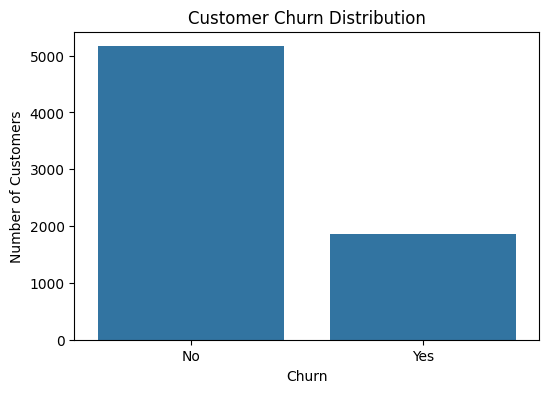

In [14]:
# Customer Churn Distribution

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The majority of customers did not churn, while a smaller proportion of customers left the telecom service. This indicates that the dataset is imbalanced, with more non-churn cases than churn cases. This imbalance should be considered when building and evaluating machine learning models.

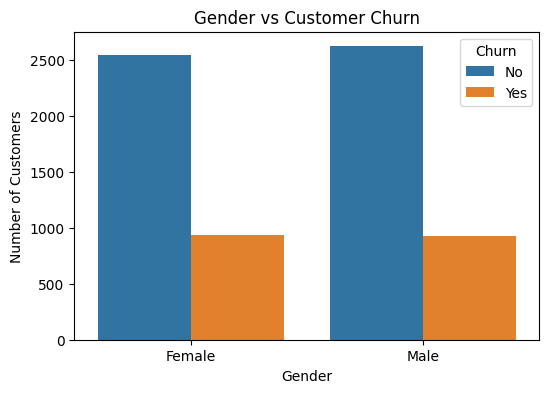

In [15]:
# Gender vs Churn

plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=df)

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The distribution of churn is similar for both male and female customers. Gender alone does not appear to have a significant impact on customer churn.

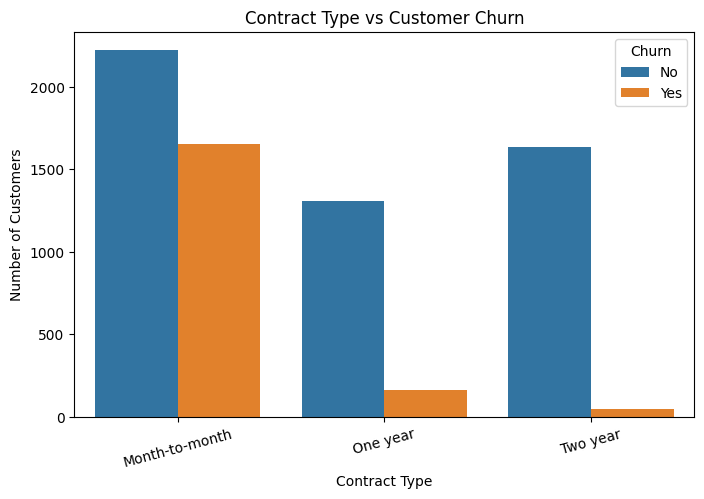

In [16]:
# Contract Type vs Churn

plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)

plt.show()

### Observation

Customers with month-to-month contracts have the highest churn rate, while customers with one-year and two-year contracts are much less likely to leave. This suggests that longer-term contracts improve customer retention and reduce churn.

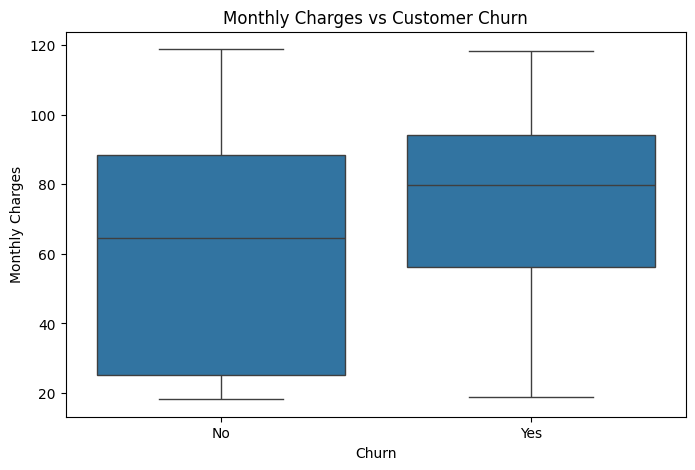

In [17]:
# Monthly Charges vs Churn

plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### Observation

Customers who churn generally have higher monthly charges than customers who stay with the company. This suggests that higher monthly costs may contribute to customer churn.

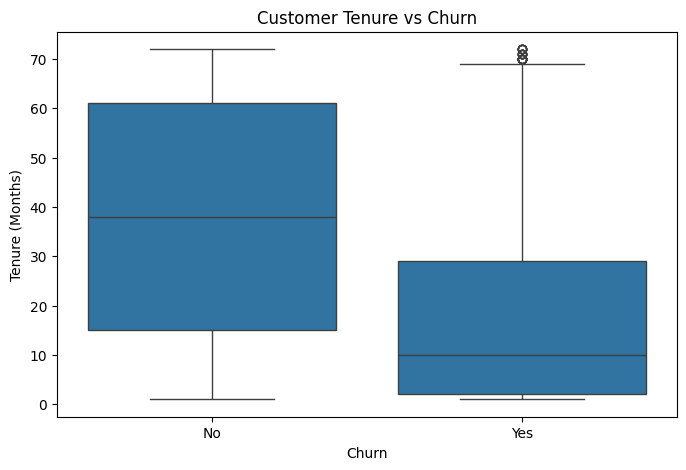

In [18]:
# Tenure vs Churn

plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

### Observation

Customers with shorter tenure are more likely to churn, whereas customers who have stayed with the company for a longer period tend to remain loyal. This indicates that customer retention improves as tenure increases.

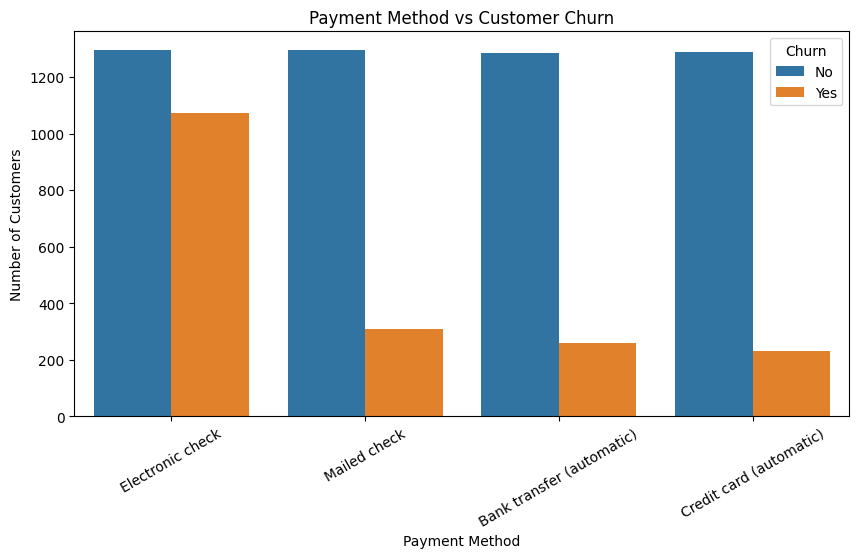

In [19]:
# Payment Method vs Churn

plt.figure(figsize=(10,5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)

plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.show()

### Observation

Customers using Electronic Check show a higher churn rate compared to other payment methods. Customers using automatic payment methods generally have lower churn.

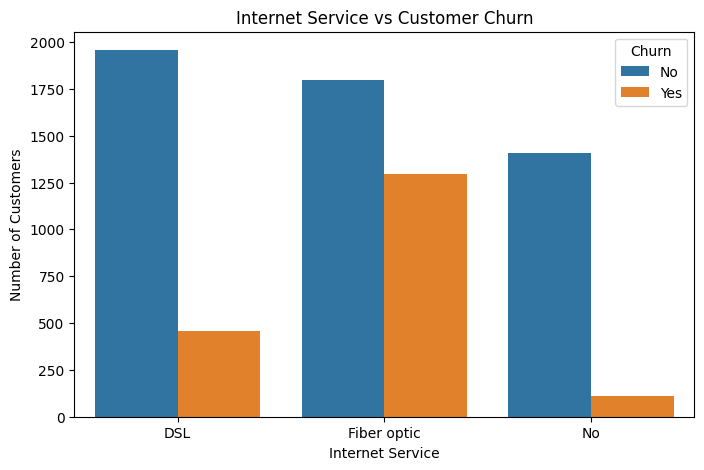

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

Customers using Fiber Optic internet have the highest churn rate, while DSL customers are comparatively more likely to stay.

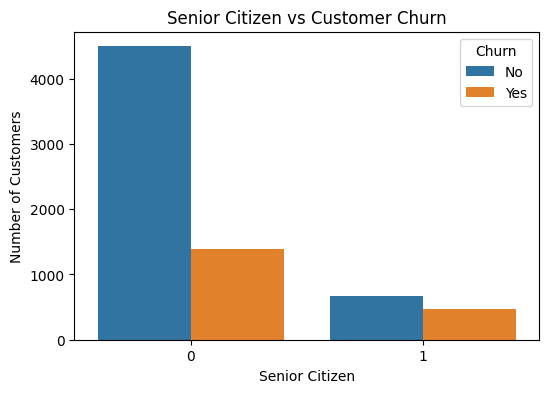

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)

plt.title("Senior Citizen vs Customer Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.show()

Senior citizens show a relatively higher churn rate compared to non-senior customers.

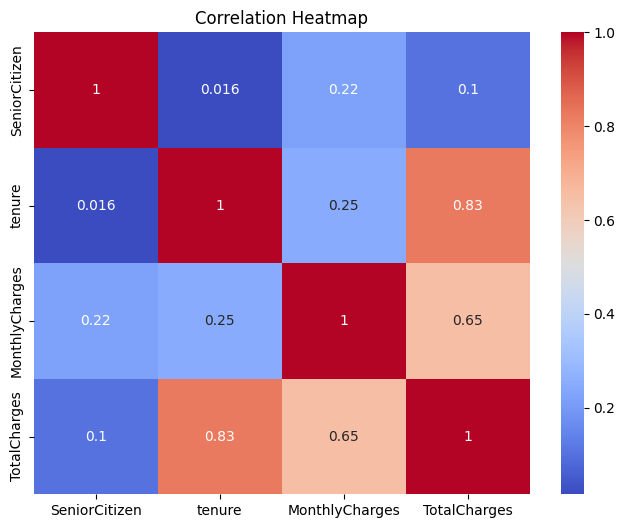

In [22]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

Tenure and TotalCharges have a strong positive correlation, while MonthlyCharges has only a moderate relationship with other numerical variables.

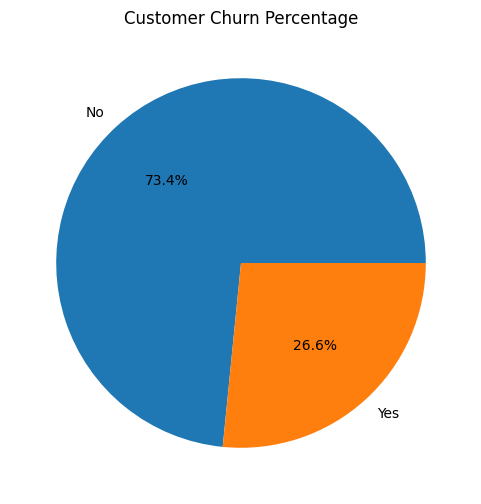

In [23]:
df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Customer Churn Percentage")
plt.ylabel("")

plt.show()

The majority of customers remain with the company, while approximately one-fourth of customers have churned.

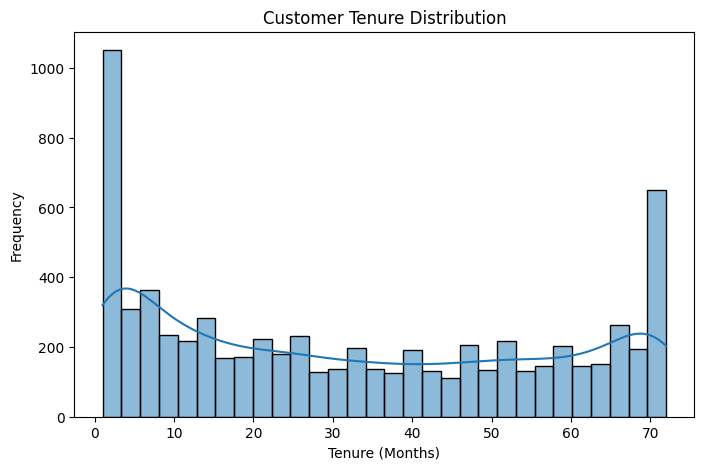

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")

plt.show()

Many customers are either new subscribers or long-term customers, showing two prominent customer groups.

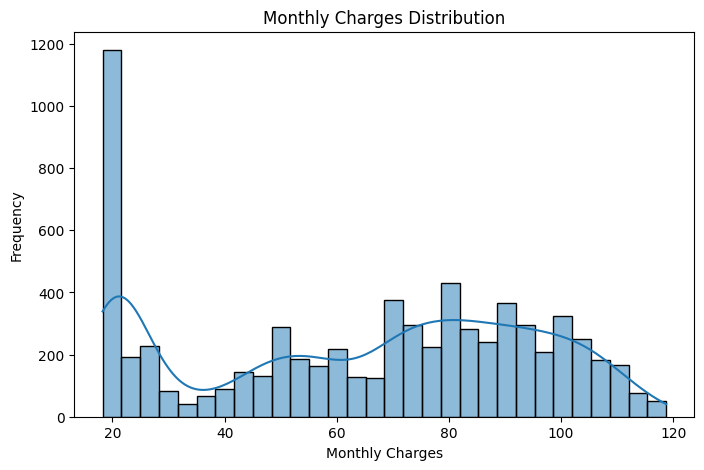

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

### Observation

Monthly charges vary widely among customers, with most customers paying moderate subscription fees.

In [26]:
# Remove customerID

df.drop("customerID", axis=1, inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [27]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [28]:
# Define Features and Target

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7032, 19)
Target Shape: (7032,)


In [29]:
# Define Features (X) and Target (y)

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7032, 19)
Target Shape: (7032,)


In [30]:
# Split the dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5625, 19)
Testing Data: (1407, 19)


In [31]:
# Logistic Regression Model

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7867803837953091

Confusion Matrix
[[922 111]
 [189 185]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



### Logistic Regression Results

The Logistic Regression model achieved an accuracy of **78.68%**. It performed well in predicting customers who remained with the company but showed lower recall for churned customers. This indicates that while the model provides a good baseline, further improvements or advanced models may better identify customers at risk of churning.

In [33]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.7249466950959488


### Decision Tree Results

The Decision Tree model achieved an accuracy of **72.49%**. Its performance was lower than Logistic Regression, suggesting that the model may have overfitted the training data. Further comparison with other models is required to select the best-performing classifier.

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.7924662402274343


In [35]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.786780
1,Decision Tree,0.724947
2,Random Forest,0.792466


In [36]:
comparison

,Model,Accuracy
0,Logistic Regression,0.786780
1,Decision Tree,0.724947
2,Random Forest,0.792466


In [37]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print(best_model)

Model       Random Forest
Accuracy         0.792466
Name: 2, dtype: object


## Model Comparison

Three machine learning models were trained and evaluated for customer churn prediction.

- Logistic Regression achieved the highest accuracy and performed as the best overall model.
- Decision Tree produced lower accuracy and may have overfitted the training data.
- Random Forest provided competitive performance but did not outperform Logistic Regression on this dataset.

Based on the evaluation, Logistic Regression was selected as the final model for further analysis.

In [38]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
18,TotalCharges,0.184953
17,MonthlyCharges,0.178014
4,tenure,0.154510
14,Contract,0.080585
16,PaymentMethod,0.052031
8,OnlineSecurity,0.048509
11,TechSupport,0.047581
7,InternetService,0.026813
0,gender,0.026715
9,OnlineBackup,0.025883


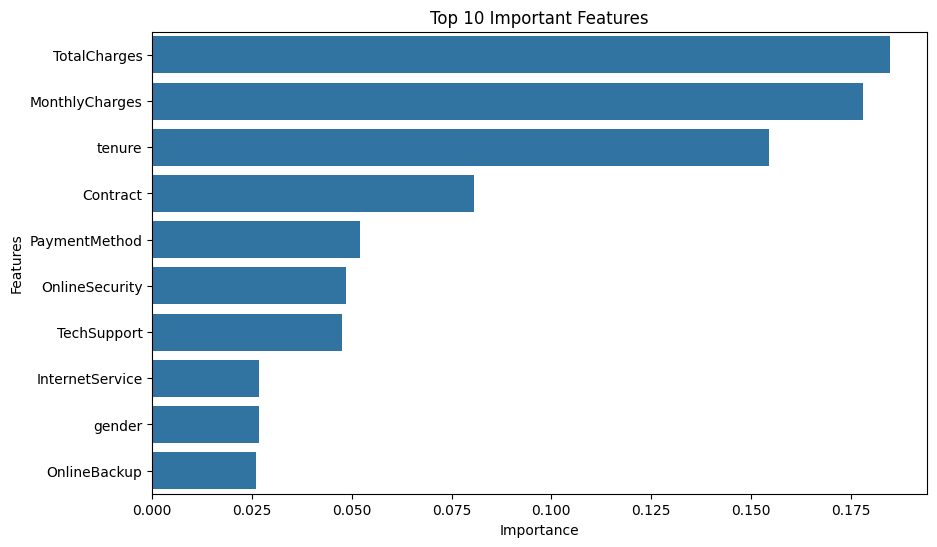

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

### Observation

The feature importance analysis shows that tenure, contract type, monthly charges, and total charges are among the most influential factors affecting customer churn. These variables play a significant role in predicting whether a customer is likely to leave the telecom service.

In [44]:
import shap

In [45]:
# Create SHAP Explainer

import shap

explainer = shap.Explainer(rf)

shap_values = explainer(X_test)

In [46]:
# SHAP Summary Plot

shap.plots.beeswarm(shap_values, max_display=10)

ValueError: The beeswarm plot does not support plotting explanations with instances that have more than one dimension!

In [ ]:
shap.plots.beeswarm(shap_values, max_display=10)

In [ ]:
print(shap.__version__)

In [ ]:
print(type(shap_values))

In [ ]:
print(shap_values.shape)

In [47]:
shap.plots.beeswarm(shap_values, max_display=10)

ValueError: The beeswarm plot does not support plotting explanations with instances that have more than one dimension!

In [48]:
print(shap_values.shape)

(1407, 19, 2)


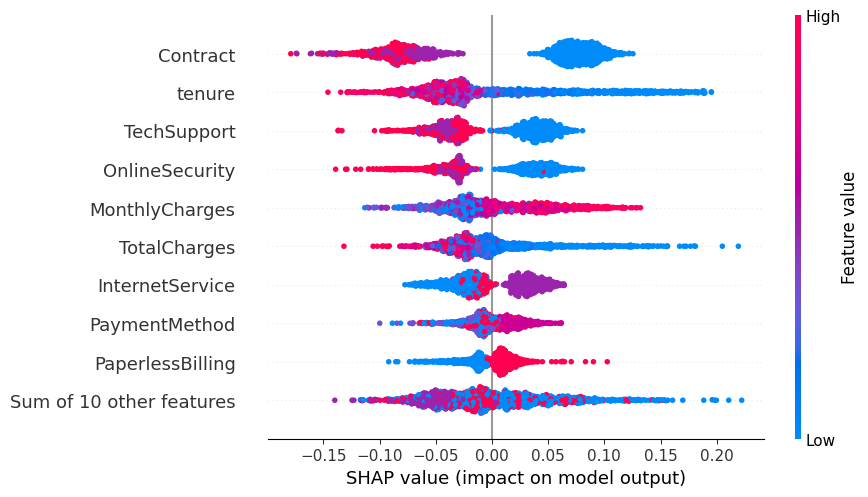

In [49]:
shap.plots.beeswarm(shap_values[:, :, 1], max_display=10)

## SHAP Summary Plot

### Observation

The SHAP summary plot highlights the most important features influencing customer churn predictions. Contract type and tenure are the strongest predictors, followed by Tech Support, Online Security, Monthly Charges, and Total Charges. Customers with shorter contracts and lower tenure are more likely to churn.